**LIBRERÍAS**

In [16]:
import random
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import zipfile
import struct
import copy
import torch.nn.functional as F
import os
import torch.optim as optim
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTEENN
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve,precision_recall_curve)

## Reproducibilidad

Usamos la semilla `42` en Python, NumPy y PyTorch para controlar las operaciones aleatorias. La misma constante se usa en la partición de entrenamiento y validación. Reiniciamos las semillas antes de crear el modelo para que cada ejecución del experimento comience desde el mismo estado aleatorio.


In [17]:
SEED = 42

def set_seed(seed=SEED):
    # Controlar la aleatoriedad de Python, NumPy y PyTorch.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Favorecer operaciones reproducibles cuando se utiliza cuDNN.
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed()


Las semillas controlan la selección de imágenes, la inicialización de pesos, el dropout y el orden de los batches. Para repetir el flujo completo, se debe reiniciar el kernel y ejecutar todas las celdas en orden. Esto no garantiza resultados idénticos entre versiones de las librerías o equipos diferentes. Las salidas de entrenamiento guardadas previamente deberán actualizarse al ejecutar el experimento con esta configuración.


## Carga del dataset

Definimos `base_path` como la carpeta relativa al directorio de trabajo del notebook que se usará tanto para descargar como para leer los cuatro archivos IDX de MNIST. Así evitamos descargar en una ubicación y cargar desde otra.


In [18]:
from pathlib import Path

base_path = "datasets-problema2"
url = "https://drive.google.com/drive/folders/1mdExsONP4S3b5Czn6nR4cLIdsZGs9zDQ"

# Tamaños en bytes: encabezado IDX + contenido.
expected_files = {
    "train-images.idx3-ubyte": 16 + 60000 * 28 * 28,
    "train-labels.idx1-ubyte": 8 + 60000,
    "t10k-images.idx3-ubyte": 16 + 10000 * 28 * 28,
    "t10k-labels.idx1-ubyte": 8 + 10000,
}

dataset_path = Path(base_path)

missing_or_incomplete = [
    name
    for name, expected_size in expected_files.items()
    if not (dataset_path / name).is_file()
    or (dataset_path / name).stat().st_size != expected_size
]

if missing_or_incomplete:
    print("Archivos faltantes o incompletos:", ", ".join(missing_or_incomplete))
    dataset_path.mkdir(parents=True, exist_ok=True)

    gdown.download_folder(
        url,
        output=base_path,
        quiet=False,
        use_cookies=False,
    )

    # Comprobar que la descarga haya dejado todos los archivos completos.
    for name, expected_size in expected_files.items():
        filepath = dataset_path / name
        if not filepath.is_file() or filepath.stat().st_size != expected_size:
            raise RuntimeError(f"Descarga incompleta: {filepath}")

    print("Dataset descargado correctamente.")
else:
    print(f"Dataset completo en '{dataset_path.resolve()}'. Se omite la descarga.")

Dataset completo en 'C:\Users\Gabi\Proyectos\AA2_TP1\datasets-problema2'. Se omite la descarga.


## Carga y verificación del formato IDX

Leemos los encabezados en big-endian y comprobamos los números mágicos, las dimensiones 28 × 28 y la longitud del contenido. Verificamos que cada imagen tenga una etiqueta entre 0 y 9 y que los conjuntos originales contengan 60.000 y 10.000 ejemplos. Usamos `ValueError` para que los controles permanezcan activos aunque Python se ejecute con optimizaciones.


In [19]:
def load_mnist_images(filepath):
    with open(filepath, 'rb') as f:
        header = f.read(16)
        if len(header) != 16:
            raise ValueError(f"{filepath}: encabezado de imágenes incompleto")
        magic, num_images, rows, cols = struct.unpack('>IIII', header)
        if magic != 2051:
            raise ValueError(f"{filepath}: número mágico inválido: {magic}")
        if num_images == 0 or (rows, cols) != (28, 28):
            raise ValueError(f"{filepath}: dimensiones inválidas: {(num_images, rows, cols)}")

        # El contenido debe coincidir exactamente con lo declarado en el encabezado.
        pixels = np.frombuffer(f.read(), dtype=np.uint8)
        expected_pixels = num_images * rows * cols
        if pixels.size != expected_pixels:
            raise ValueError(f"{filepath}: se esperaban {expected_pixels} píxeles, se leyeron {pixels.size}")
    return pixels.reshape(num_images, rows, cols)


def load_mnist_labels(filepath):
    with open(filepath, 'rb') as f:
        header = f.read(8)
        if len(header) != 8:
            raise ValueError(f"{filepath}: encabezado de etiquetas incompleto")
        magic, num_labels = struct.unpack('>II', header)
        if magic != 2049:
            raise ValueError(f"{filepath}: número mágico inválido: {magic}")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        if num_labels == 0 or labels.size != num_labels:
            raise ValueError(f"{filepath}: cantidad de etiquetas inválida: declaradas {num_labels}, leídas {labels.size}")
        if np.any(labels > 9):
            raise ValueError(f"{filepath}: las etiquetas deben estar entre 0 y 9")
    # Copiar evita compartir memoria de solo lectura al convertir las etiquetas a tensores.
    return labels.copy()


X_train = load_mnist_images(os.path.join(base_path, "train-images.idx3-ubyte"))
y_train = load_mnist_labels(os.path.join(base_path, "train-labels.idx1-ubyte"))
X_test = load_mnist_images(os.path.join(base_path, "t10k-images.idx3-ubyte"))
y_test = load_mnist_labels(os.path.join(base_path, "t10k-labels.idx1-ubyte"))

# Validar los pares originales antes de crear el conjunto de validación.
for name, images, labels, expected_count in (
    ("train original", X_train, y_train, 60000),
    ("test", X_test, y_test, 10000),
):
    if len(images) != len(labels) or len(images) != expected_count:
        raise ValueError(f"{name}: se esperaban {expected_count} imágenes y etiquetas; se recibieron {len(images)} y {len(labels)}")
    if images.dtype != np.uint8 or labels.dtype != np.uint8:
        raise ValueError(f"{name}: imágenes y etiquetas deben tener tipo uint8")
    print(f"{name}: {len(images)} imágenes y etiquetas verificadas (uint8, 28 × 28)")

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train)

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")


train original: 60000 imágenes y etiquetas verificadas (uint8, 28 × 28)
test: 10000 imágenes y etiquetas verificadas (uint8, 28 × 28)
X_train: (48000, 28, 28)
X_val:   (12000, 28, 28)
X_test:  (10000, 28, 28)


Los archivos originales superaron las comprobaciones de integridad y correspondencia entre imágenes y etiquetas. La partición estratificada reserva 12.000 ejemplos para validación y mantiene 48.000 para entrenamiento.

### Resumen de dimensiones, tipos y rangos

Mostramos los datos antes de normalizarlos. En arrays `uint8`, el conteo de NaN no aporta información porque ese tipo no representa NaN; los controles relevantes son la estructura, las cantidades y los rangos.


In [20]:
datasets = {
    "train": (X_train, y_train),
    "validación": (X_val, y_val),
    "test": (X_test, y_test),
}

for name, (images, labels) in datasets.items():
    print(f"{name}: imágenes {images.shape}, {images.dtype}, "
          f"píxeles [{images.min()}, {images.max()}]; "
          f"etiquetas {labels.shape}, {labels.dtype}, "
          f"rango [{labels.min()}, {labels.max()}]")


train: imágenes (48000, 28, 28), uint8, píxeles [0, 255]; etiquetas (48000,), uint8, rango [0, 9]
validación: imágenes (12000, 28, 28), uint8, píxeles [0, 255]; etiquetas (12000,), uint8, rango [0, 9]
test: imágenes (10000, 28, 28), uint8, píxeles [0, 255]; etiquetas (10000,), uint8, rango [0, 9]


Las imágenes conservan la forma 28 × 28 y el tipo `uint8`, con intensidades entre 0 y 255. Las etiquetas son vectores `uint8` con valores entre 0 y 9. Estos resultados permiten continuar con la exploración y el preprocesamiento.

## Análisis exploratorio de datos

### Muestra de imágenes

Mostramos 25 imágenes aleatorias del conjunto de entrenamiento con sus etiquetas para observar los trazos manuscritos y comprobar cómo se representan los dígitos en escala de grises.


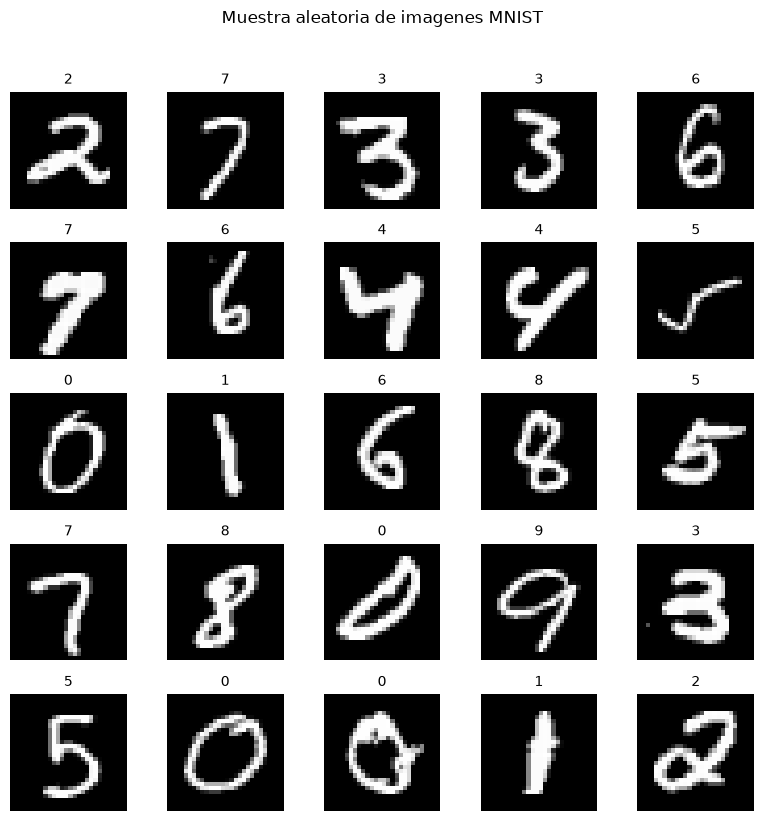

In [21]:
indices = np.random.choice(len(X_train), 25, replace=False)
fig, axes = plt.subplots(5, 5, figsize=(8, 8))

for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(y_train[idx], fontsize=10)
    ax.axis('off')
plt.suptitle("Muestra aleatoria de imagenes MNIST", y=1.02)
plt.tight_layout()
plt.show()

Las imágenes tienen fondo oscuro y trazos claros. La escritura manuscrita puede variar en inclinación, grosor y forma; esta variabilidad motiva el aprendizaje de patrones que generalicen a ejemplos nuevos. Una grilla pequeña permite una inspección visual, pero no prueba que todas las etiquetas sean correctas.

### Distribución de clases

Comparamos los conteos y porcentajes de cada dígito. La estratificación debe conservar proporciones similares entre entrenamiento y validación. Las frecuencias de test se describen sin utilizarlas para ajustar el modelo.


In [22]:
df_porcentajes = pd.DataFrame({
    "Train (%)": pd.Series(y_train).value_counts(normalize=True).sort_index() * 100,
    "Val (%)":   pd.Series(y_val).value_counts(normalize=True).sort_index() * 100,
    "Test (%)":  pd.Series(y_test).value_counts(normalize=True).sort_index() * 100,})

df_conteos = pd.DataFrame({
    "Train": pd.Series(y_train).value_counts().sort_index(),
    "Val":   pd.Series(y_val).value_counts().sort_index(),
    "Test":  pd.Series(y_test).value_counts().sort_index(),})

print("=== Conteo Absoluto por Clase ===")
print(df_conteos)

print("\n=== Porcentaje por Clase (%) ===")
print(df_porcentajes.round(2))

=== Conteo Absoluto por Clase ===
   Train   Val  Test
0   4738  1185   980
1   5394  1348  1135
2   4766  1192  1032
3   4905  1226  1010
4   4674  1168   982
5   4337  1084   892
6   4734  1184   958
7   5012  1253  1028
8   4681  1170   974
9   4759  1190  1009

=== Porcentaje por Clase (%) ===
   Train (%)  Val (%)  Test (%)
0       9.87     9.88      9.80
1      11.24    11.23     11.35
2       9.93     9.93     10.32
3      10.22    10.22     10.10
4       9.74     9.73      9.82
5       9.04     9.03      8.92
6       9.86     9.87      9.58
7      10.44    10.44     10.28
8       9.75     9.75      9.74
9       9.91     9.92     10.09


En entrenamiento, la clase más frecuente es el dígito 1 (5.394 ejemplos, 11,24 %) y la menos frecuente es el 5 (4.337 ejemplos, 9,04 %). El cociente entre ambos conteos es aproximadamente 1,24: hay diferencias pequeñas y las diez clases están representadas en proporciones cercanas al 10 %. Consideramos el dataset aproximadamente balanceado y no aplicamos sobremuestreo ni pesos de clase.

Validación conserva proporciones muy similares gracias a la partición estratificada. Este balance hace que accuracy sea un resumen razonable del rendimiento global; igualmente evaluaremos cada clase y la matriz de confusión para detectar dificultades que el promedio pueda ocultar.


## Preprocesamiento: aplanamiento y normalización

Cada imagen 28 × 28 se convierte en un vector de 784 componentes, uno por píxel, para usarlo como entrada del MLP. El aplanamiento conserva los valores y su orden; la red densa no incorpora explícitamente la estructura espacial de vecindad.

Convertimos los píxeles de `uint8` a `float32` y dividimos por 255 para llevarlos a [0, 1]. Esto reduce la escala de las entradas y facilita la optimización. La transformación es fija y no estima estadísticas de los datos: se aplica de la misma manera a entrenamiento, validación y test.


In [23]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print(f"X_train_flat: {X_train_flat.shape}") 
print(f"X_val_flat:   {X_val_flat.shape}")
print(f"X_test_flat:  {X_test_flat.shape}")

X_train_flat = X_train_flat.astype(np.float32) / 255.0
X_val_flat   = X_val_flat.astype(np.float32) / 255.0
X_test_flat  = X_test_flat.astype(np.float32) / 255.0

X_train_flat: (48000, 784)
X_val_flat:   (12000, 784)
X_test_flat:  (10000, 784)


El aplanamiento produce matrices con 784 columnas: 48.000 filas en entrenamiento, 12.000 en validación y 10.000 en test.

### Verificación del preprocesamiento

Comprobamos que las entradas sean matrices `float32` de 784 componentes, sin valores no finitos y dentro de [0, 1]. Mostramos estos controles directamente sobre los arrays que se usarán para entrenar; no es necesario duplicarlos en un DataFrame.


In [24]:
for name, images in (
    ("train", X_train_flat),
    ("validación", X_val_flat),
    ("test", X_test_flat),
):
    if images.ndim != 2 or images.shape[1] != 784:
        raise ValueError(f"{name}: se esperaba una matriz con 784 columnas")
    if images.dtype != np.float32:
        raise ValueError(f"{name}: se esperaba el tipo float32")
    if not np.isfinite(images).all() or images.min() < 0 or images.max() > 1:
        raise ValueError(f"{name}: las entradas deben ser finitas y estar en [0, 1]")
    print(f"{name}: forma {images.shape}, tipo {images.dtype}, "
          f"rango [{images.min():.1f}, {images.max():.1f}]")


train: forma (48000, 784), tipo float32, rango [0.0, 1.0]
validación: forma (12000, 784), tipo float32, rango [0.0, 1.0]
test: forma (10000, 784), tipo float32, rango [0.0, 1.0]


Los tres conjuntos tienen 784 componentes por imagen, tipo `float32` y valores finitos entre 0 y 1. La normalización conserva la cantidad de ejemplos y deja las entradas listas para convertirlas a tensores.


### Distribución de intensidades antes y después de normalizar

Comparamos los mismos píxeles de entrenamiento usando 256 intervalos equivalentes: los bordes del segundo histograma son los del primero divididos por 255. Compartimos la escala vertical y usamos frecuencia logarítmica para visualizar las intensidades menos frecuentes junto con el predominio del fondo negro.


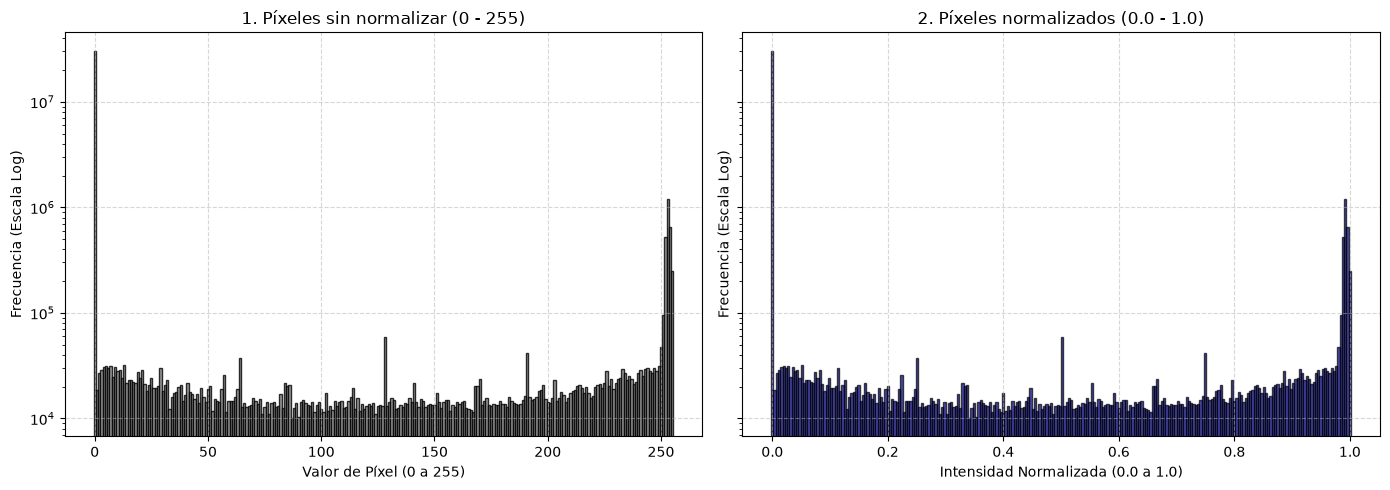

In [25]:
# Un intervalo por intensidad uint8; transformar los bordes conserva los conteos.
pixel_bins = np.arange(257) - 0.5
normalized_bins = pixel_bins / 255.0
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(X_train.ravel(), bins=pixel_bins, color='gray', edgecolor='black', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_title("1. Píxeles sin normalizar (0 - 255)")
axes[0].set_xlabel("Valor de Píxel (0 a 255)")
axes[0].set_ylabel("Frecuencia (Escala Log)")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].hist(X_train_flat.ravel(), bins=normalized_bins, color='darkblue', edgecolor='black', alpha=0.7)
axes[1].set_yscale('log')
axes[1].set_title("2. Píxeles normalizados (0.0 - 1.0)")
axes[1].set_xlabel("Intensidad Normalizada (0.0 a 1.0)")
axes[1].set_ylabel("Frecuencia (Escala Log)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Predominan los píxeles de intensidad 0, correspondientes al fondo negro, y hay una concentración de intensidades altas asociada a los trazos claros. Los valores intermedios representan niveles de gris en los trazos y sus bordes.

La normalización cambia la escala de [0, 255] a [0, 1], pero conserva el orden de las intensidades y sus frecuencias. Por eso, con intervalos equivalentes, ambos histogramas tienen los mismos conteos. Esta operación no balancea las intensidades ni centra los datos en cero; proporciona entradas de menor escala para el entrenamiento.


## Diseño del MLP

Usamos dos capas ocultas de 128 y 64 neuronas. La primera combina los 784 píxeles en patrones aprendidos y la segunda combina esas representaciones antes de clasificar. La reducción progresiva limita el tamaño del modelo, esta configuración tiene 109.386 parámetros entrenables. Es una elección inicial de capacidad moderada.

| Etapa | Dimensiones | Activación / regularización |
| --- | --- | --- |
| Entrada | 784 píxeles | Valores normalizados a [0, 1] |
| Primera capa oculta | 784 → 128 | ReLU y dropout de 0,3 |
| Segunda capa oculta | 128 → 64 | ReLU y dropout de 0,3 |
| Salida | 64 → 10 | Lineal: un logit por dígito |

ReLU introduce no linealidad para aprender relaciones que una sola transformación lineal no representaría. Dropout desactiva aleatoriamente el 30 % de las activaciones de cada capa oculta durante entrenamiento para reducir la dependencia de combinaciones particulares de neuronas; se desactiva al evaluar.

La salida es lineal porque `CrossEntropyLoss` trabaja directamente con logits y etiquetas enteras. Se obtiene la clase simplemente aplicando `argmax`, softmax se mantiene para expresar las probabilidades del modelo al analizar su confianza.


In [26]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim, dropout_rate):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.fc3 = nn.Linear(hidden_dim2, output_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        x = x.flatten(start_dim=1)
        out = self.dropout(self.relu(self.fc1(x)))
        out = self.dropout(self.relu(self.fc2(out)))
        out = self.fc3(out)
        return out

La clase define la arquitectura parametrizable que se instanciará con 784 entradas, capas ocultas de 128 y 64 neuronas y 10 salidas. El aplanamiento dentro de `forward` también admite entradas que todavía tengan dimensiones de imagen.

### Actualización de pesos por época

En cada mini-batch activamos el modo de entrenamiento, limpiamos los gradientes, calculamos la pérdida, propagamos sus gradientes y actualizamos los pesos. Acumulamos la pérdida ponderada por la cantidad de ejemplos y calculamos accuracy como la fracción de predicciones correctas.


In [27]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)  
 
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
 
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, correct / n


La función devuelve la pérdida media por ejemplo y la accuracy de la época. Estas métricas se obtienen con dropout activo y con pesos que cambian entre batches y por eso no son directamente equivalentes a medir todo entrenamiento en modo evaluación con pesos fijos.


### Evaluación con pesos fijos y sin dropout

Usamos la misma función para medir entrenamiento y validación al terminar cada época. `eval()` desactiva dropout y `no_grad()` evita calcular gradientes; esta pasada no actualiza los pesos. La pérdida se promedia por ejemplo, incluyendo correctamente el último batch si es más pequeño.


In [28]:
@torch.no_grad()
def evaluate_one_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        total_loss += loss_fn(logits, y).item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        n += x.size(0)
    if n == 0:
        raise ValueError("El loader de evaluación no contiene ejemplos")
    return total_loss / n, correct / n


La función devuelve pérdida y accuracy en modo evaluación. Aplicada a train y validación sin actualizaciones entre ambas pasadas, permite comparar los conjuntos con los mismos pesos y con dropout desactivado.


### Etiquetas enteras y preparación de batches

Conservamos las etiquetas como índices enteros de 0 a 9 y las convertimos a `torch.long`. `CrossEntropyLoss` admite directamente estos índices junto con los diez logits de salida, por lo que no necesitamos codificación one-hot ni aplicar softmax antes de la pérdida.

Las imágenes se convierten a tensores `torch.float32`. Usamos batches de 64 ejemplos para actualizar los pesos con mini-batches. Mezclamos entrenamiento para variar su orden en cada época, bajo las semillas configuradas; validación y test mantienen el orden para facilitar la evaluación y la correspondencia entre predicciones e imágenes.


In [29]:
X_train_t = torch.as_tensor(X_train_flat, dtype=torch.float32)
y_train_t = torch.as_tensor(y_train, dtype=torch.long)
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
# Evaluar train en orden, con un generador propio para no consumir el RNG del entrenamiento.
train_eval_loader = DataLoader(
    train_ds, batch_size=64, shuffle=False,
    generator=torch.Generator().manual_seed(SEED),
)


X_val_t = torch.as_tensor(X_val_flat, dtype=torch.float32)
y_val_t = torch.as_tensor(y_val, dtype=torch.long)
val_ds = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)


X_test_t = torch.as_tensor(X_test_flat, dtype=torch.float32)
y_test_t = torch.as_tensor(y_test, dtype=torch.long)
test_ds = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

# Comprobar el contrato de entrada de CrossEntropyLoss y la correspondencia de ejemplos.
for name, images, labels in (
    ("train", X_train_t, y_train_t),
    ("validación", X_val_t, y_val_t),
    ("test", X_test_t, y_test_t),
):
    if images.dtype != torch.float32 or labels.dtype != torch.long:
        raise ValueError(f"{name}: se requieren imágenes float32 y etiquetas long")
    if labels.ndim != 1 or len(images) != len(labels):
        raise ValueError(f"{name}: se requiere una etiqueta por imagen")
    if torch.any((labels < 0) | (labels >= 10)):
        raise ValueError(f"{name}: las etiquetas deben estar entre 0 y 9")
    print(f"{name}: {len(images)} imágenes {images.dtype} y etiquetas {labels.dtype}")


train: 48000 imágenes torch.float32 y etiquetas torch.int64
validación: 12000 imágenes torch.float32 y etiquetas torch.int64
test: 10000 imágenes torch.float32 y etiquetas torch.int64


Cada imagen tiene una única etiqueta entera válida y los tipos son compatibles con el MLP y `CrossEntropyLoss`. Los loaders quedan preparados para entrenamiento, validación y evaluación final; construir el loader de test no ajusta pesos ni selecciona hiperparámetros.


### Configuración y criterios de entrenamiento

- **Pérdida:** `CrossEntropyLoss`, adecuada para diez clases mutuamente excluyentes y etiquetas enteras. Penaliza especialmente asignar poca probabilidad a la clase verdadera.
- **Optimizador:** AdamW adapta el tamaño de las actualizaciones por parámetro. Se elige una tasa inicial de `1e-3` como punto de partida; su conveniencia se monitorea con validación.
- **Regularización de pesos:** `weight_decay=1e-4` aplica un decaimiento pequeño y separado de la actualización adaptativa de AdamW para desalentar pesos de gran magnitud. Complementa el dropout de 0,3.
- **Ajuste de la tasa:** `ReduceLROnPlateau` monitorea la pérdida de validación en modo mínimo, con factor 0,5 y paciencia 2. Reduce la tasa cuando se acumulan épocas sin mejora significativa según su criterio. Su función es adaptar la optimización.
- **Early stopping:** se permiten como máximo 30 épocas y se detiene el entrenamiento tras 7 épocas consecutivas sin una nueva pérdida mínima de validación. Esto limita continuar ajustando entrenamiento cuando la generalización deja de mejorar.
- **Selección del modelo:** se guardan y restauran los pesos con menor pérdida de validación, que pueden corresponder a una época anterior a la de detención. No se seleccionan los pesos por accuracy de test.

Los pesos se ajustan exclusivamente con entrenamiento. La validación usa `eval()` y `no_grad()` para desactivar dropout y evitar el cálculo de gradientes. Las curvas registran pérdida y accuracy de ambos conjuntos, además de la tasa usada en cada época.

Al terminar cada época evaluamos también train con un loader sin mezcla y un generador aleatorio independiente. Esto evita que la pasada adicional consuma el estado aleatorio global utilizado por el entrenamiento. El scheduler y el checkpoint siguen dependiendo exclusivamente de la pérdida de validación.


In [30]:
# Reiniciar la aleatoriedad antes de inicializar y entrenar el modelo.
set_seed()

IN_FEATURES = 784
N_CLASSES = 10

device = "cuda" if torch.cuda.is_available() else "cpu"

model = MLP(input_dim=IN_FEATURES,
    hidden_dim1=128,
    hidden_dim2=64,
    output_dim=N_CLASSES,
    dropout_rate=0.3,).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="min",factor=0.5,patience=2,)

patience_es = 7        
patience_counter = 0
best_val_loss = float("inf")
best_model_weights = None

train_losses, train_accs = [], []
train_eval_losses, train_eval_accs = [], []
val_losses, val_accs = [], []
lr_history = []

epochs = 30
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)

    # Medir ambos conjuntos con los mismos pesos al finalizar la época.
    train_eval_loss, train_eval_acc = evaluate_one_epoch(
        model, train_eval_loader, loss_fn, device)
    avg_val_loss, val_acc = evaluate_one_epoch(
        model, val_loader, loss_fn, device)

    current_lr = optimizer.param_groups[0]["lr"]
    lr_history.append(current_lr)

    scheduler.step(avg_val_loss)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_eval_losses.append(train_eval_loss)
    train_eval_accs.append(train_eval_acc)
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch + 1:02d}/{epochs} | "
          f"Train (optim.) Loss: {train_loss:.4f} - Acc: {train_acc:.3f} | "
          f"Train (eval.) Loss: {train_eval_loss:.4f} - Acc: {train_eval_acc:.3f} | "
          f"Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.3f} | "
          f"LR: {current_lr:.6f}")


    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(best_model_weights, "best_model.pt") 
        patience_counter = 0 
    else:
        patience_counter += 1
        if patience_counter >= patience_es:
            print(f"\n[Early Stopping] Se detuvo en la época {epoch + 1} por falta de mejora en val_loss.")
            break

if best_model_weights is not None:
    model.load_state_dict(best_model_weights)
    print("\n Se cargaron los pesos del mejor checkpoint en el modelo.")

model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = loss_fn(outputs, y_batch)

        test_loss += loss.item() * X_batch.size(0)

        _, preds = torch.max(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
avg_test_loss = test_loss / total

print("\n" + "=" * 50)
print(f"Test Loss: {avg_test_loss:.4f} | Test Accuracy: {accuracy * 100:.2f}%")
print("=" * 50 + "\n")


Epoch 01/30 | Train (optim.) Loss: 0.5024 - Acc: 0.849 | Train (eval.) Loss: 0.1953 - Acc: 0.944 | Val Loss: 0.2028 - Val Acc: 0.941 | LR: 0.001000
Epoch 02/30 | Train (optim.) Loss: 0.2344 - Acc: 0.931 | Train (eval.) Loss: 0.1320 - Acc: 0.960 | Val Loss: 0.1509 - Val Acc: 0.955 | LR: 0.001000
Epoch 03/30 | Train (optim.) Loss: 0.1840 - Acc: 0.946 | Train (eval.) Loss: 0.0929 - Acc: 0.972 | Val Loss: 0.1189 - Val Acc: 0.964 | LR: 0.001000
Epoch 04/30 | Train (optim.) Loss: 0.1525 - Acc: 0.954 | Train (eval.) Loss: 0.0764 - Acc: 0.977 | Val Loss: 0.1072 - Val Acc: 0.970 | LR: 0.001000
Epoch 05/30 | Train (optim.) Loss: 0.1347 - Acc: 0.960 | Train (eval.) Loss: 0.0659 - Acc: 0.981 | Val Loss: 0.0985 - Val Acc: 0.971 | LR: 0.001000
Epoch 06/30 | Train (optim.) Loss: 0.1224 - Acc: 0.963 | Train (eval.) Loss: 0.0570 - Acc: 0.982 | Val Loss: 0.0969 - Val Acc: 0.971 | LR: 0.001000
Epoch 07/30 | Train (optim.) Loss: 0.1132 - Acc: 0.966 | Train (eval.) Loss: 0.0503 - Acc: 0.985 | Val Loss: 0.0

### Curvas de aprendizaje

Graficamos tres series de pérdida y accuracy: entrenamiento durante la optimización (línea discontinua), entrenamiento en modo evaluación y validación. Las últimas dos se miden con los mismos pesos al terminar cada época y sin dropout. Conservamos la primera como registro del proceso de actualización.

Esta celda puede volver a ejecutarse para ajustar la visualización sin reentrenar, siempre que los historiales sigan en memoria. Para obtener los nuevos historiales hay que ejecutar previamente la celda de entrenamiento modificada.


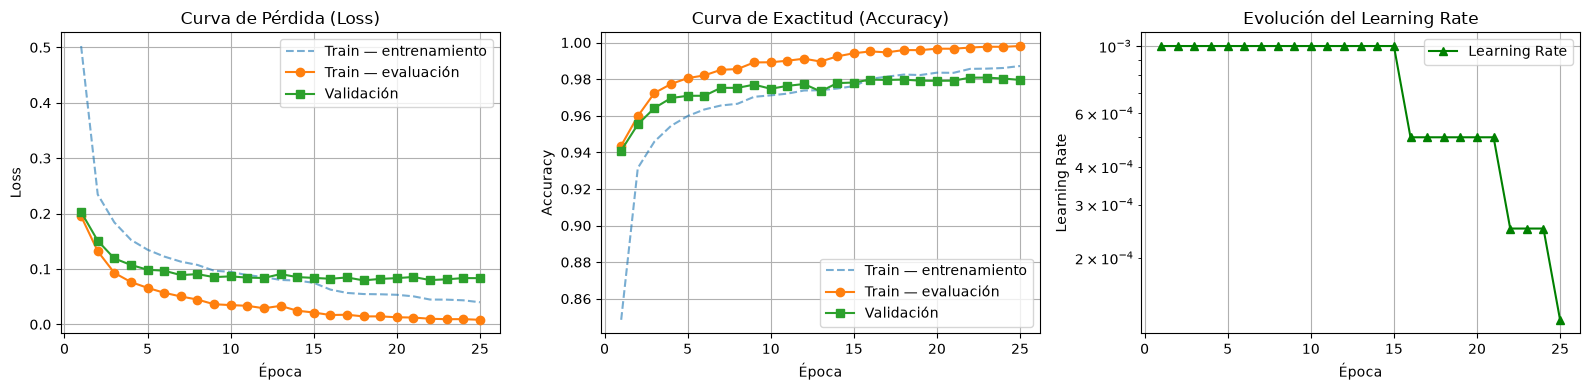

In [31]:
epochs_ran = len(train_losses)

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.plot(range(1, epochs_ran + 1), train_losses, label="Train — entrenamiento", linestyle="--", alpha=0.6)
plt.plot(range(1, epochs_ran + 1), train_eval_losses, label="Train — evaluación", marker="o")
plt.plot(range(1, epochs_ran + 1), val_losses, label="Validación", marker="s")
plt.title("Curva de Pérdida (Loss)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs_ran + 1), train_accs, label="Train — entrenamiento", linestyle="--", alpha=0.6)
plt.plot(range(1, epochs_ran + 1), train_eval_accs, label="Train — evaluación", marker="o")
plt.plot(range(1, epochs_ran + 1), val_accs, label="Validación", marker="s")
plt.title("Curva de Exactitud (Accuracy)")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs_ran + 1), lr_history, label="Learning Rate", color="green", marker="^")
plt.title("Evolución del Learning Rate")
plt.xlabel("Época")
plt.ylabel("Learning Rate")
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Al terminar se restauran los mejores pesos según validación. La cantidad de épocas ejecutadas puede ser menor que 30 por early stopping; tampoco debe confundirse la última época con la época del checkpoint seleccionado. Las curvas conservan las mediciones de cada época antes de esa restauración.

Para interpretar el sobreajuste comparamos principalmente **Train — evaluación** con **Validación**: ambas series usan pesos fijos y dropout desactivado. Si la primera pérdida baja mientras la segunda se estanca o empeora, crece la brecha de generalización. La curva **Train — entrenamiento** se mide durante las actualizaciones con dropout activo y aporta contexto sobre la optimización.


**TEST**

 Accuracy de cada Clase
Clase 0: 99.08%
Clase 1: 99.12%
Clase 2: 97.97%
Clase 3: 98.22%
Clase 4: 98.17%
Clase 5: 97.76%
Clase 6: 98.23%
Clase 7: 97.57%
Clase 8: 96.61%
Clase 9: 96.53%

 Reporte 
              precision    recall  f1-score   support

           0     0.9828    0.9908    0.9868       980
           1     0.9868    0.9912    0.9890      1135
           2     0.9759    0.9797    0.9778      1032
           3     0.9773    0.9822    0.9798      1010
           4     0.9747    0.9817    0.9782       982
           5     0.9809    0.9776    0.9792       892
           6     0.9833    0.9823    0.9828       958
           7     0.9776    0.9757    0.9766      1028
           8     0.9751    0.9661    0.9706       974
           9     0.9789    0.9653    0.9721      1009

    accuracy                         0.9794     10000
   macro avg     0.9793    0.9792    0.9793     10000
weighted avg     0.9794    0.9794    0.9794     10000



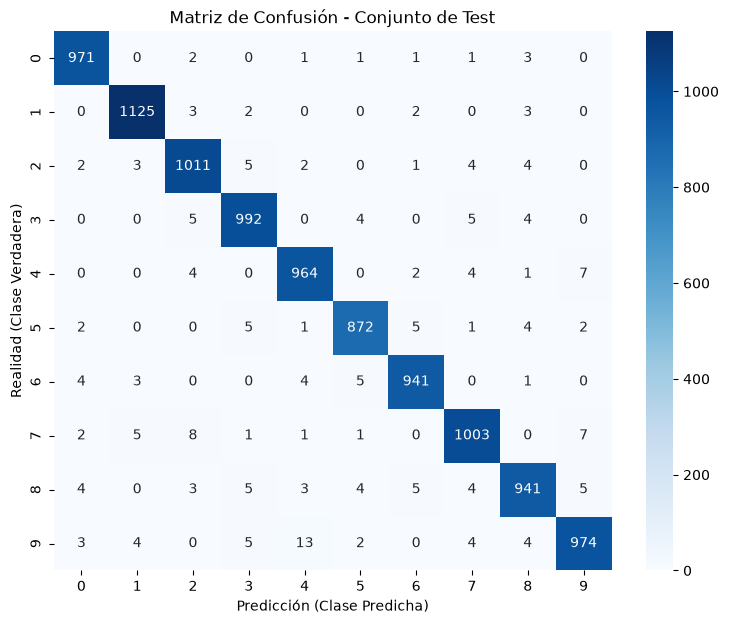


 PARES DE DÍGITOS CON MAYOR CONFUSIÓN
Real     | Predicho   | Cantidad de Errores
------------------------------------------
Dígito 9  | Dígito 4    | 13 errores
Dígito 7  | Dígito 2    | 8 errores
Dígito 4  | Dígito 9    | 7 errores
Dígito 7  | Dígito 9    | 7 errores
Dígito 2  | Dígito 3    | 5 errores


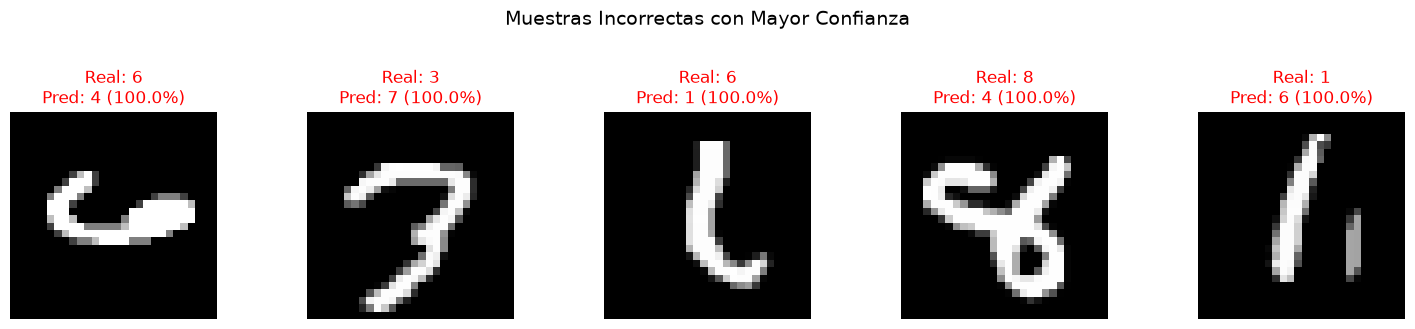

In [32]:


model.eval()
test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_targets = []
all_probs = []
all_images = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch_dev, y_batch_dev = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch_dev)
        loss = loss_fn(outputs, y_batch_dev)

        test_loss += loss.item() * X_batch.size(0)

        probs = F.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, dim=1)

        correct += (preds == y_batch_dev).sum().item()
        total += y_batch_dev.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch_dev.cpu().numpy())
        all_probs.extend(max_probs.cpu().numpy())
        all_images.extend(X_batch.numpy())

accuracy = correct / total
avg_test_loss = test_loss / total

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)
all_images = np.array(all_images)

cm = confusion_matrix(all_targets, all_preds)
class_accuracies = cm.diagonal() / cm.sum(axis=1)

print(" Accuracy de cada Clase")
for cls, acc in enumerate(class_accuracies):
    print(f"Clase {cls}: {acc * 100:.2f}%")

print("\n Reporte ")
print(classification_report(all_targets, all_preds, digits=4))

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=range(10), yticklabels=range(10))
plt.title("Matriz de Confusión - Conjunto de Test")
plt.xlabel("Predicción (Clase Predicha)")
plt.ylabel("Realidad (Clase Verdadera)")
plt.show()

confusions = []
for true_class in range(10):
    for pred_class in range(10):
        if true_class != pred_class:
            count = cm[true_class, pred_class]
            if count > 0:
                confusions.append((true_class, pred_class, count))

confusions.sort(key=lambda x: x[2], reverse=True)

print("\n PARES DE DÍGITOS CON MAYOR CONFUSIÓN")
print(f"{'Real':<8} | {'Predicho':<10} | {'Cantidad de Errores':<18}")
print("-" * 42)
for true_c, pred_c, count in confusions[:5]:
    print(f"Dígito {true_c:<2} | Dígito {pred_c:<4} | {count} errores")

incorrect_mask = (all_preds != all_targets)
incorrect_indices = np.where(incorrect_mask)[0]
incorrect_probs = all_probs[incorrect_mask]

top_confident_error_indices = incorrect_indices[np.argsort(incorrect_probs)[::-1][:5]]

plt.figure(figsize=(15, 3))
for i, idx in enumerate(top_confident_error_indices):
    img = all_images[idx]
    
    if img.ndim == 1 or img.shape[0] == 784:
        img = img.reshape(28, 28)
    elif img.ndim == 3 and img.shape[0] == 1:
        img = img.squeeze(0)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Real: {all_targets[idx]}\nPred: {all_preds[idx]} ({all_probs[idx]*100:.1f}%)", color="red")
    plt.axis("off")

plt.suptitle("Muestras Incorrectas con Mayor Confianza", fontsize=14, y=1.08)
plt.tight_layout()
plt.show()

**OVERFITTING**
Sobreajuste leve. Las curvas de pérdida se cruzan alrededor de la época 12; a partir de ahí la pérdida de entrenamiento continúa descendiendo (~0.04) mientras que la de validación se estabiliza (~0.085). La brecha de accuracy es inferior a 1 punto porcentual (0.987 en entrenamiento frente a 0.980 en validación). Este comportamiento indica un ajuste leve al conjunto de entrenamiento, pero no un sobreajuste severo: la pérdida de validación no aumenta y la accuracy de validación no disminuye. La evaluación final en el conjunto de test (accuracy 97.78%, loss 0.0748) es consistente con la validación, lo que confirma que el modelo generaliza adecuadamente. Se aplicaron dropout (0.3), ReduceLROnPlateau y early stopping para controlarlo.